In [1]:
import netCDF4
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import concurrent.futures
import os
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir('../')

In [2]:
## Load historical data
historical = pd.read_csv('Outputs/Climate_data_extraction/all_points_monthly_data_hist.csv')
historical['month_year'] = pd.to_datetime(historical['month_year'])
historical['Year'] = historical['month_year'].dt.year
historical

,point_name,month_year,TBOT_avg,PRECTmms_total_mm,Year
0,2_6_105_51297,1951-01-01,271.91070,358.180660,1951
1,2_6_105_51297,1951-02-01,272.65640,213.483550,1951
2,2_6_105_51297,1951-03-01,274.52300,65.060490,1951
3,2_6_105_51297,1951-04-01,281.72113,54.694458,1951
4,2_6_105_51297,1951-05-01,284.21075,139.791350,1951
...,...,...,...,...,...
481315,5_6_109_75599,2020-08-01,297.12050,1.044510,2020
481316,5_6_109_75599,2020-09-01,296.21988,2.156096,2020
481317,5_6_109_75599,2020-10-01,291.02524,0.000443,2020
481318,5_6_109_75599,2020-11-01,281.40317,71.043210,2020


In [3]:
## Calculate baseline climate
baseline_y1 = 1981
baseline_yf = 2010

## Aggregate annual values for each point
hist_ann = historical.loc[(historical['month_year'].dt.year >= baseline_y1) & (historical['month_year'].dt.year <= baseline_yf)].groupby(['point_name', 'Year'], as_index = False).agg({'TBOT_avg':'mean', 'PRECTmms_total_mm':'sum'})

## Aggregate 30-year average by point
hist_point = hist_ann.groupby('point_name', as_index = False)[['TBOT_avg', 'PRECTmms_total_mm']].agg('mean')
hist_point.rename(columns = {
    'TBOT_avg': 'TBOT_hist',
    'PRECTmms_total_mm': 'PRECT_hist'
}, inplace = True)

hist_point

,point_name,TBOT_hist,PRECT_hist
0,2_6_105_51218,279.569713,2291.451536
1,2_6_105_51297,281.932972,1781.351034
2,2_6_105_52478,281.715400,1720.651011
3,2_6_105_53434,282.961276,1942.994212
4,2_6_105_55197,282.055787,1928.960412
...,...,...,...
568,5_6_9_76472,283.115620,1833.804652
569,5_6_9_76890,289.230705,764.075274
570,5_6_9_77228,280.968061,1871.885179
571,5_6_9_78914,287.219770,1346.668074


In [4]:
def get_gcm_results(gcm):
    results = pd.read_csv('Outputs/Climate_data_extraction/all_points_monthly_data_{}_ssp370_bc.csv'.format(gcm))

    results['month_year'] = pd.to_datetime(results['month_year'])
    results['Year'] = results['month_year'].dt.year
    
    out = results.groupby(
        ['point_name', 'Year'], as_index=False).agg({
        'TBOT_avg':'mean', 
        'PRECTmms_total_mm':'sum'
    })

    out['GCM'] = gcm

    return out

def get_anomaly_table(df):
    anmly_tbl = pd.merge(hist_point, df, how = 'inner', on = 'point_name')
    anmly_tbl['TBOT_anmly_deg'] = anmly_tbl['TBOT_avg'] - anmly_tbl['TBOT_hist']
    anmly_tbl['PREC_anmly_pct'] = (anmly_tbl['PRECTmms_total_mm'] - anmly_tbl['PRECT_hist'])/anmly_tbl['PRECT_hist'] * 100
    return anmly_tbl

In [5]:
results_dict = {}

for g in ['cesm2', 'canesm5', 'fgoals']:
    temp = get_gcm_results(g)
    results_dict[g] = get_anomaly_table(temp)

all_gcms = pd.concat(results_dict.values(), ignore_index=True)
all_gcms

,point_name,TBOT_hist,PRECT_hist,Year,TBOT_avg,PRECTmms_total_mm,GCM,TBOT_anmly_deg,PREC_anmly_pct
0,2_6_105_51218,279.569713,2291.451536,2014,280.093898,1847.081729,cesm2,0.524184,-19.392503
1,2_6_105_51218,279.569713,2291.451536,2015,281.731067,1714.237707,cesm2,2.161353,-25.189877
2,2_6_105_51218,279.569713,2291.451536,2016,280.688371,2351.262970,cesm2,1.118657,2.610199
3,2_6_105_51218,279.569713,2291.451536,2017,281.324788,2603.679404,cesm2,1.755075,13.625768
4,2_6_105_51218,279.569713,2291.451536,2018,281.694045,1385.600091,cesm2,2.124332,-39.531774
...,...,...,...,...,...,...,...,...,...
149548,5_6_9_83898,283.889052,1712.275057,2096,287.234268,3299.696319,fgoals,3.345216,92.708310
149549,5_6_9_83898,283.889052,1712.275057,2097,287.269798,2557.890633,fgoals,3.380746,49.385499
149550,5_6_9_83898,283.889052,1712.275057,2098,287.270742,2808.430900,fgoals,3.381690,64.017509
149551,5_6_9_83898,283.889052,1712.275057,2099,287.776623,1824.042686,fgoals,3.887571,6.527434


In [6]:
# Filter plots
min_plots = pd.read_csv('Outputs/sampled_fia_plots_81_kenStone.csv')

# Check that each row is a unique plot
assert len(min_plots) == len(min_plots['PLT_CN'].unique())

all_gcms_min_plots = all_gcms.loc[all_gcms['point_name'].isin(min_plots['pltID'].unique())]

## Check that all plots in the minimal list are accounted for
assert len(min_plots['PLT_CN'].unique()) == len(all_gcms_min_plots['point_name'].unique())

In [7]:
## Calculate moving average anomaly

def add_mvng_avg_col(df, num_yrs):
    ## Sort by time
    out = df.sort_values(by = ['point_name', 'GCM', 'Year']).copy()

    out['TBOT_{}yr_avg'.format(num_yrs)] = out.groupby(['point_name', 'GCM'])['TBOT_anmly_deg'].rolling(window = num_yrs).mean().droplevel([0,1])
    out['PREC_{}yr_avg'.format(num_yrs)] = out.groupby(['point_name', 'GCM'])['PREC_anmly_pct'].rolling(window = num_yrs).mean().droplevel([0,1])

    return out

all_gcms_min_plots = add_mvng_avg_col(all_gcms_min_plots, 10)
all_gcms_min_plots

,point_name,TBOT_hist,PRECT_hist,Year,TBOT_avg,PRECTmms_total_mm,GCM,TBOT_anmly_deg,PREC_anmly_pct,TBOT_10yr_avg,PREC_10yr_avg
50460,2_6_105_62696,279.774966,1775.638607,2014,279.485367,299.944010,canesm5,-0.289599,-83.107823,NaN,NaN
50461,2_6_105_62696,279.774966,1775.638607,2015,281.155393,1781.276170,canesm5,1.380426,0.317495,NaN,NaN
50462,2_6_105_62696,279.774966,1775.638607,2016,280.884581,2075.107101,canesm5,1.109614,16.865397,NaN,NaN
50463,2_6_105_62696,279.774966,1775.638607,2017,280.667804,719.333988,canesm5,0.892838,-59.488717,NaN,NaN
50464,2_6_105_62696,279.774966,1775.638607,2018,281.583747,1085.839625,canesm5,1.808780,-38.847938,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
149374,5_6_9_77228,280.968061,1871.885179,2096,284.371997,3603.875943,fgoals,3.403937,92.526549,3.428850,46.843141
149375,5_6_9_77228,280.968061,1871.885179,2097,284.415759,2978.895377,fgoals,3.447698,59.138788,3.481158,48.176005
149376,5_6_9_77228,280.968061,1871.885179,2098,284.398777,3205.554374,fgoals,3.430716,71.247383,3.484428,54.757216
149377,5_6_9_77228,280.968061,1871.885179,2099,284.880540,2082.209801,fgoals,3.912479,11.235979,3.556022,52.257002


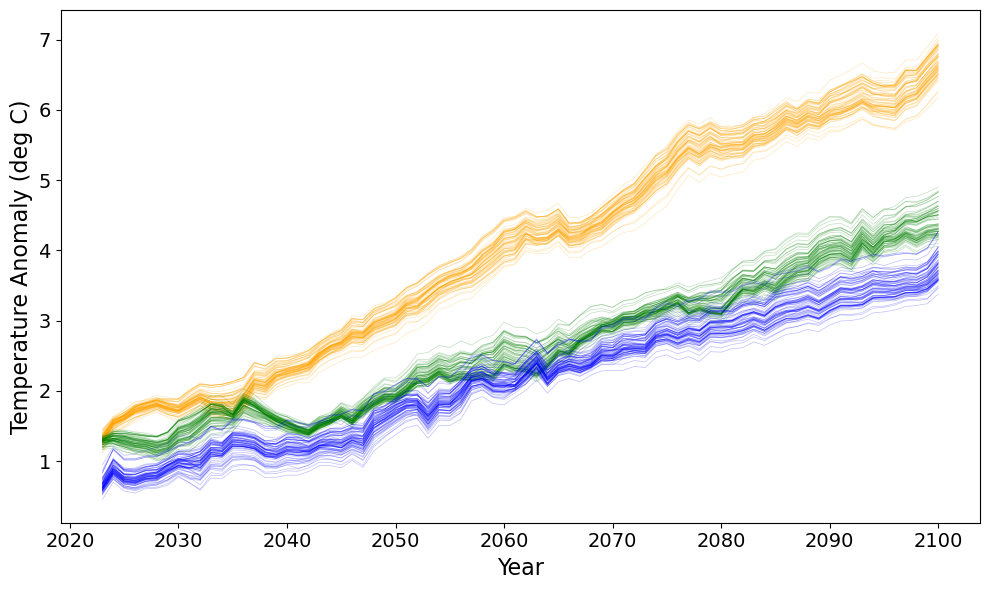

In [8]:
# Plot smoothed temperature anomaly over time
color_map = {'canesm5': 'orange', 'cesm2':'green', 'fgoals':'blue'}

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=all_gcms_min_plots,
    x='Year',
    y='TBOT_10yr_avg',
    hue='GCM',
    units='point_name',      # Draw a separate line for each plot
    estimator=None,       # Plot the raw data
    lw=0.5,               # Use a thin line
    alpha=0.25,             # Make lines transparent,
    palette = color_map
)
# plt.title('Projected Temperature Anomaly')
plt.xlabel('Year', fontsize =16)
plt.ylabel('Temperature Anomaly (deg C)', fontsize = 16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend().remove()
# Move legend outside the plot
# plt.legend(title='Climate Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

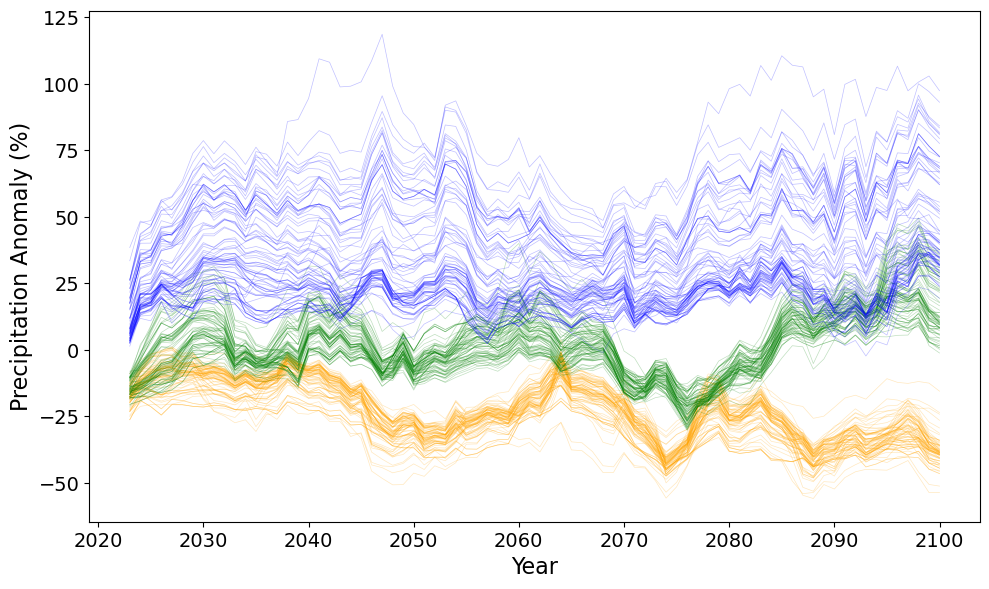

In [9]:
# Plot smoothed precipitation over time
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=all_gcms_min_plots,
    x='Year',
    y='PREC_10yr_avg',
    hue='GCM',
    units='point_name',      # Draw a separate line for each plot
    estimator=None,       # Plot the raw data
    lw=0.5,               # Use a thin line
    alpha=0.25,             # Make lines transparent, 
    palette = color_map
)
# plt.title('Projected Precipitation Anomaly')
plt.xlabel('Year', fontsize = 16)
plt.ylabel('Precipitation Anomaly (%)', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend().remove()
# Move legend outside the plot
# plt.legend(title='Climate Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()